
[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


Loaded base history:      30 epochs
Loaded finetune history:  20 epochs



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


ValueError: x and y must have same first dimension, but have shapes (50,) and (20,)

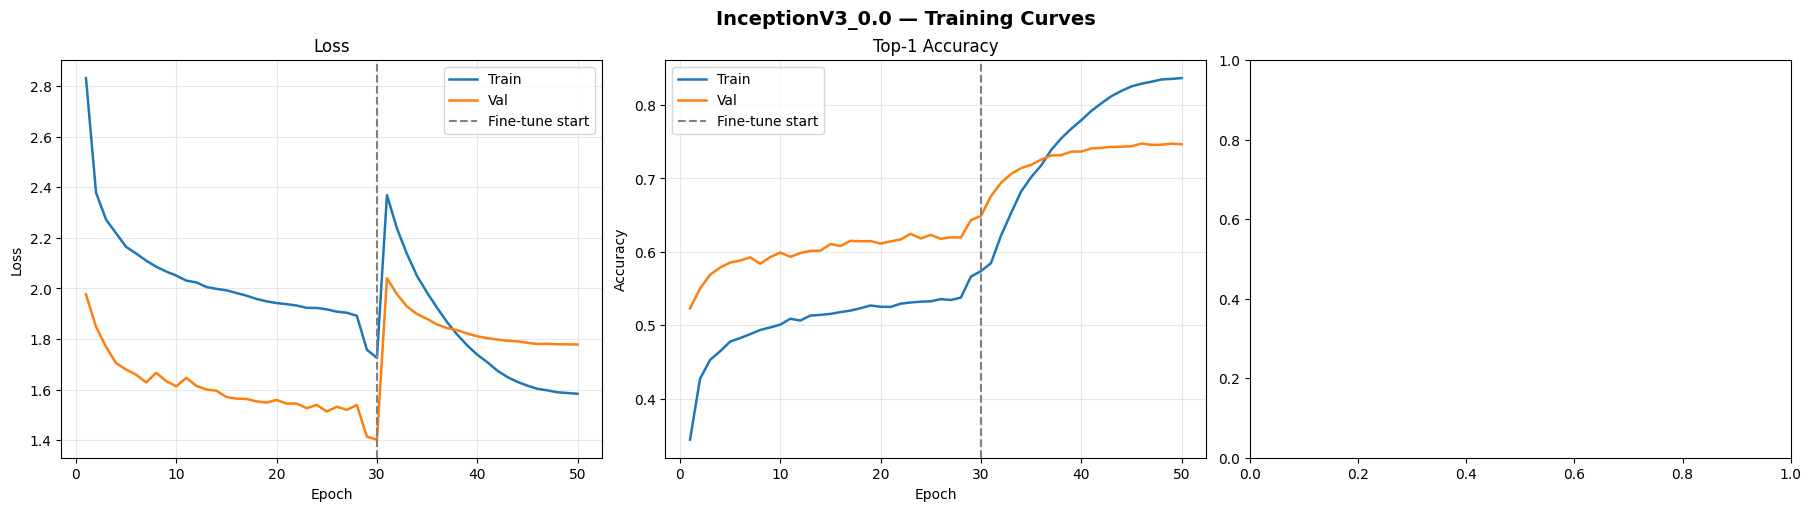

In [9]:
import subprocess
subprocess.run(["pip", "install", "pandas", "-q"], check=True)
# subprocess.run(["pip", "install", "seaborn", "-q"], check=True)
subprocess.run(["pip", "install", "seaborn", "scikit-learn", "-q"], check=True)

import matplotlib.pyplot as plt
import pandas as pd
import os

# -- Config
MODEL_NAME = "InceptionV3_0.0"
BASE_DIR   = "/tf/data/models"
SAVE_DIR   = f"{BASE_DIR}/{MODEL_NAME}"

# -- Paths (derived, do not edit)
base_log = f"{SAVE_DIR}/{MODEL_NAME}_history_base.log"
ft_log   = f"{SAVE_DIR}/{MODEL_NAME}_history_finetuned.log"
out_path = f"{SAVE_DIR}/{MODEL_NAME}_training_curves.png"

# -- Load histories
h_base = pd.read_csv(base_log)
print(f"Loaded base history:      {len(h_base)} epochs")

h_ft = None
phase_boundary = len(h_base)
if os.path.exists(ft_log):
    h_ft = pd.read_csv(ft_log)
    print(f"Loaded finetune history:  {len(h_ft)} epochs")
else:
    print(f"No finetune log found at {ft_log!r} — plotting base phase only")

# -- Helper
def col(df, key):
    if df is not None and key in df.columns:
        return list(df[key])
    return []

# -- Combine phases
loss     = col(h_base, "loss")         + col(h_ft, "loss")
val_loss = col(h_base, "val_loss")     + col(h_ft, "val_loss")
acc      = col(h_base, "accuracy")     + col(h_ft, "accuracy")
val_acc  = col(h_base, "val_accuracy") + col(h_ft, "val_accuracy")
top5     = col(h_base, "top5_acc")     + col(h_ft, "top5_acc")
val_top5 = col(h_base, "val_top5_acc") + col(h_ft, "val_top5_acc")

epochs = list(range(1, len(loss) + 1))

# -- Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle(f"{MODEL_NAME} — Training Curves", fontsize=14, fontweight="bold")

axes[0].plot(epochs, loss,     label="Train", linewidth=1.8)
axes[0].plot(epochs, val_loss, label="Val",   linewidth=1.8)
if h_ft is not None:
    axes[0].axvline(phase_boundary, color="gray", linestyle="--", label="Fine-tune start")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, acc,     label="Train", linewidth=1.8)
axes[1].plot(epochs, val_acc, label="Val",   linewidth=1.8)
if h_ft is not None:
    axes[1].axvline(phase_boundary, color="gray", linestyle="--", label="Fine-tune start")
axes[1].set_title("Top-1 Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

if top5:
    axes[2].plot(epochs, top5,     label="Train", linewidth=1.8)
    axes[2].plot(epochs, val_top5, label="Val",   linewidth=1.8)
    if h_ft is not None:
        axes[2].axvline(phase_boundary, color="gray", linestyle="--", label="Fine-tune start")
    axes[2].set_title("Top-5 Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Accuracy")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].set_visible(False)

plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

Loading best_model_finetuned.keras from /tf/data/models/InceptionV3_0.0/InceptionV3_0.0_final.keras...


I0000 00:00:1778063217.009226     442 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5590 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:06:00.0, compute capability: 8.6


NameError: name 'build_dataset' is not defined